# customer churn analysis project

In [1]:
## import all require libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#import the datasets
customer=pd.read_csv('customers.csv')
service=pd.read_csv('services.csv')
locat=pd.read_csv('locations.csv')
status=pd.read_csv('status.csv')

In [3]:
# standardize the column name 
customer.columns= customer.columns.str.lower().str.replace(" ", "_")
service.columns= service.columns.str.lower().str.replace(" ", "_")
locat.columns= locat.columns.str.lower().str.replace(" ", "_")
status.columns= status.columns.str.lower().str.replace(" ", "_")

In [4]:
locat.rename(columns={'customerid':'customer_id'},inplace=True)

In [5]:
df =customer.merge(service, on='customer_id', how='inner').merge(status, on='customer_id', how='inner').merge(locat, on='customer_id', how='left')


In [6]:
df.head(5)

,customer_id,gender,age,under_30,senior_citizen,married,dependents,number_of_dependents,referred_a_friend,number_of_referrals,...,churn_score,cltv,churn_category,churn_reason,country,state,city,zip_code,latitude,longitude
0,8779-QRDMV,Male,78,No,Yes,No,No,0,No,0,...,91,5433,Competitor,Competitor offered more data,United States,California,Los Angeles,90022,34.023810,-118.156582
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,Yes,1,...,69,5302,Competitor,Competitor made better offer,United States,California,Los Angeles,90063,34.044271,-118.185237
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,No,0,...,81,3179,Competitor,Competitor made better offer,United States,California,Los Angeles,90065,34.108833,-118.229715
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,Yes,1,...,88,5337,Dissatisfaction,Limited range of services,United States,California,Inglewood,90303,33.936291,-118.332639
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,Yes,1,...,67,2793,Price,Extra data charges,United States,California,Whittier,90602,33.972119,-118.020188


In [7]:
df.shape

(7043, 50)

# **data cleaning**

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   customer_id                        7043 non-null   object 
 1   gender                             7043 non-null   object 
 2   age                                7043 non-null   int64  
 3   under_30                           7043 non-null   object 
 4   senior_citizen                     7043 non-null   object 
 5   married                            7043 non-null   object 
 6   dependents                         7043 non-null   object 
 7   number_of_dependents               7043 non-null   int64  
 8   referred_a_friend                  7043 non-null   object 
 9   number_of_referrals                7043 non-null   int64  
 10  tenure_in_months                   7043 non-null   int64  
 11  offer                              3166 non-null   objec

In [9]:
df.isna().sum()

customer_id                             0
gender                                  0
age                                     0
under_30                                0
senior_citizen                          0
married                                 0
dependents                              0
number_of_dependents                    0
referred_a_friend                       0
number_of_referrals                     0
tenure_in_months                        0
offer                                3877
phone_service                           0
avg_monthly_long_distance_charges       0
multiple_lines                          0
internet_service                        0
internet_type                        1526
avg_monthly_gb_download                 0
online_security                         0
online_backup                           0
device_protection_plan                  0
premium_tech_support                    0
streaming_tv                            0
streaming_movies                  

In [10]:
df['offer'].unique()

array([nan, 'Offer E', 'Offer D', 'Offer C', 'Offer B', 'Offer A'],
      dtype=object)

In [58]:
df['offer'].fillna('not available',inplace=True)

C:\Users\ACER\AppData\Local\Temp\ipykernel_14076\2940871057.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['offer'].fillna('not available',inplace=True)


In [59]:
df['internet_type'].unique()

array(['DSL', 'Fiber Optic', 'Cable', 'no mentioned'], dtype=object)

In [60]:
df['internet_type'].fillna('no mentioned',inplace=True)

C:\Users\ACER\AppData\Local\Temp\ipykernel_14076\444344810.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['internet_type'].fillna('no mentioned',inplace=True)


In [61]:
df['churn_category'].fillna('no mentioned',inplace=True)

KeyError: 'churn_category'

In [ ]:
df['churn_reason'].fillna('no mentioned',inplace=True)

In [ ]:
print("Nulls after:", df.isnull().sum().sum())

# ***rename and drop columns***

In [ ]:
df.drop(columns=['under_30', 'senior_citizen'],inplace=True)

In [ ]:
df.drop(columns=['avg_monthly_gb_download'],inplace=True)

In [ ]:
df.drop(columns=['referred_a_friend','customer_status'],inplace=True)

In [ ]:
df.drop(columns=['total_long_distance_charges'],inplace=True)

In [ ]:
df[['state','country','quarter','churn_label','churn_value']]

In [ ]:
df.drop(
    columns=['state','country','latitude', 'longitude','streaming_movies', 'streaming_music','quarter','churn_label','churn_score','churn_category'],inplace=True
)

In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
df.head(3)

In [ ]:
df.shape

In [ ]:
df.columns=df.columns.str.strip()

In [ ]:
df.rename(columns={'number_of_dependents':'no_of_depends','number_of_referrals':'no_of_referrals','tenure_in_months':'tenure',
                   'avg_monthly_long_distance_charges':'long_distance_charrge','device_protection_plan':'device_protection','premium_tech_support':'primium_support',
                  'total_extra_data_charges':'extradata_charge','total_revenue':'revenue','satisfaction_score':'rating','payment_method':'pay_method'},inplace=True)

In [ ]:
df.head(2)

In [ ]:
df.dtypes

# ***churn overview***

In [ ]:
churn_rate=round((df['churn_value'].sum()/len(df))*100,2)
print('overall churn rate',churn_rate)

In [ ]:
df['churn_value'].value_counts()

In [ ]:
df['churn_value'].value_counts()

#  ** feature engineering**

In [ ]:
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 36, 60, 100],
    labels=['0-12', '12-24', '24-36', '36-60', '60+']
)


In [62]:
df['age_group']=pd.cut(
    df['age'],bins=[18,35,50,65,85],
    labels=['18-35','35-50','50-65','65-80']
)

In [63]:
df.groupby('churn_reason')['churn_value'].sum().sort_values(ascending=False)

churn_reason
Competitor had better devices                313
Competitor made better offer                 311
Attitude of support person                   220
Don't know                                   130
Competitor offered more data                 117
Competitor offered higher download speeds    100
Attitude of service provider                  94
Price too high                                78
Product dissatisfaction                       77
Network reliability                           72
Long distance charges                         64
Service dissatisfaction                       63
Moved                                         46
Extra data charges                            39
Limited range of services                     37
Poor expertise of online support              31
Lack of affordable download/upload speed      30
Lack of self-service on Website               29
Poor expertise of phone support               12
Deceased                                       6
no ment

In [64]:
def churn_bucket(reason):
    if 'Competitor' in reason:
        return 'Competitor'
    elif 'Price' in reason or 'charges' in reason:
        return 'Pricing'
    elif 'Service' in reason:
        return 'Service Quality'
    elif 'speed' in reason:
        return 'network issue'
    elif 'Lack of' in reason:
        return 'service'
    else:
        return 'Other'

df['reason_bucket'] =df['churn_reason'].apply(churn_bucket)
df['reason_bucket'].value_counts()


reason_bucket
Other              5899
Competitor          841
Pricing             181
Service Quality      63
network issue        30
service              29
Name: count, dtype: int64

In [65]:
df['age_group'].describe()

count      7043
unique        4
top       18-35
freq       2169
Name: age_group, dtype: object

# visualizations

In [66]:
df.head(2)

,customer_id,gender,age,married,dependents,no_of_depends,no_of_referrals,tenure,offer,phone_service,long_distance_charrge,multiple_lines,internet_service,internet_type,online_security,online_backup,device_protection,primium_support,streaming_tv,unlimited_data,contract,paperless_billing,pay_method,monthly_charge,total_charges,total_refunds,extradata_charge,revenue,rating,churn_value,cltv,churn_reason,city,zip_code,tenure_group,age_group,reason_bucket
0,8779-QRDMV,Male,78,No,No,0,0,1,not available,No,0.00,No,Yes,DSL,No,No,Yes,No,No,No,Month-to-Month,Yes,Bank Withdrawal,39.65,39.65,0.0,20,59.65,3,1,5433,Competitor offered more data,Los Angeles,90022,0-12,65-80,Competitor
1,7495-OOKFY,Female,74,Yes,Yes,1,1,8,Offer E,Yes,48.85,Yes,Yes,Fiber Optic,No,Yes,No,No,No,Yes,Month-to-Month,Yes,Credit Card,80.65,633.30,0.0,0,1024.10,3,1,5302,Competitor made better offer,Los Angeles,90063,0-12,65-80,Competitor


In [67]:
df.columns

Index(['customer_id', 'gender', 'age', 'married', 'dependents',
       'no_of_depends', 'no_of_referrals', 'tenure', 'offer', 'phone_service',
       'long_distance_charrge', 'multiple_lines', 'internet_service',
       'internet_type', 'online_security', 'online_backup',
       'device_protection', 'primium_support', 'streaming_tv',
       'unlimited_data', 'contract', 'paperless_billing', 'pay_method',
       'monthly_charge', 'total_charges', 'total_refunds', 'extradata_charge',
       'revenue', 'rating', 'churn_value', 'cltv', 'churn_reason', 'city',
       'zip_code', 'tenure_group', 'age_group', 'reason_bucket'],
      dtype='object')

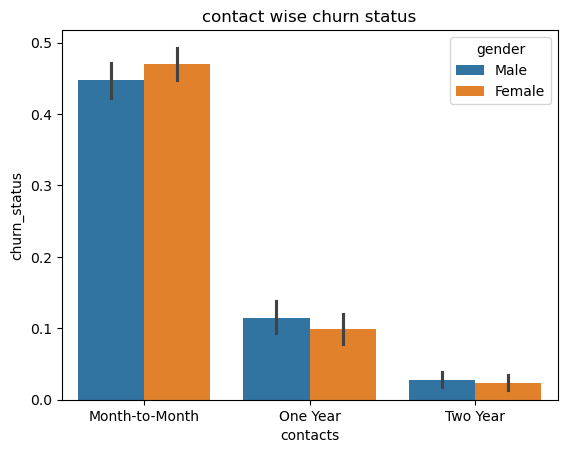

In [68]:
sns.barplot(data=df,x='contract',y='churn_value',hue='gender')

plt.xlabel('contacts')
plt.ylabel('churn_status')
plt.title('contact wise churn status')
plt.show()

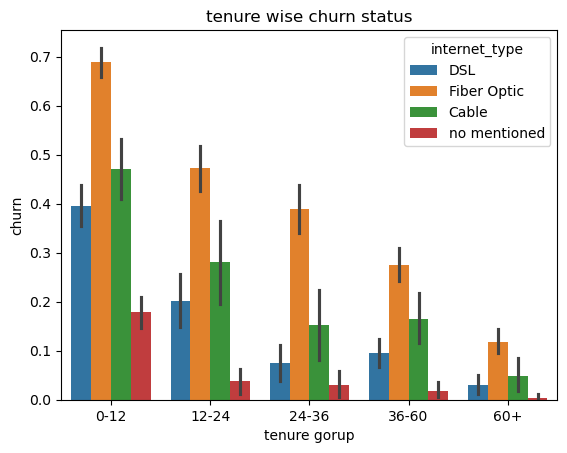

In [69]:
sns.barplot(data=df,x='tenure_group',y='churn_value',hue='internet_type')
plt.xlabel('tenure gorup')
plt.ylabel('churn')
plt.title('tenure wise churn status')
plt.show()

In [70]:
revenue=df.groupby(df['churn_value']==1)['revenue'].sum()
revenue 

churn_value
False    17686671.87
True      3684459.82
Name: revenue, dtype: float64

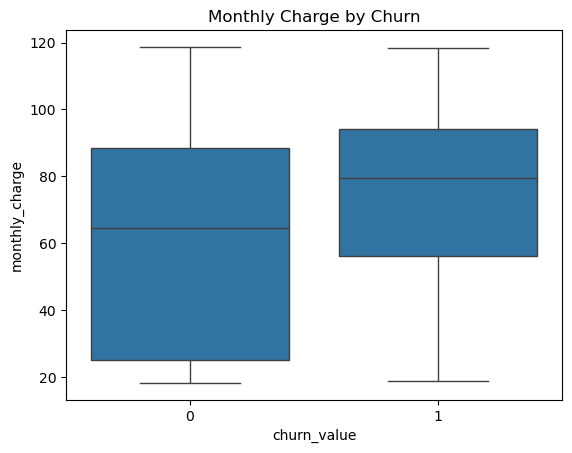

In [71]:
sns.boxplot(data=df, x='churn_value', y='monthly_charge')
plt.title('Monthly Charge by Churn')
plt.show()

Text(0.5, 1.0, 'tenure vs revenue')

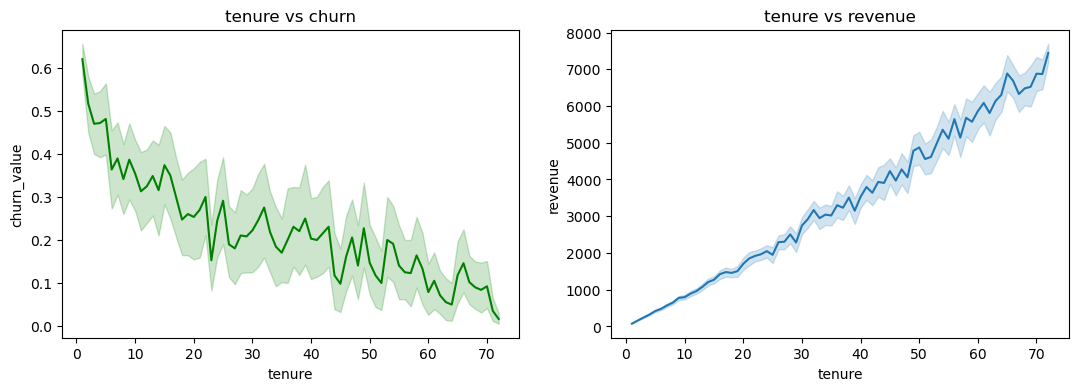

In [72]:
plt.figure(figsize=(13,4))
plt.subplot(1,2,1)
sns.lineplot(data=df,x='tenure',y='churn_value',color='green')
plt.title('tenure vs churn')

plt.subplot(1,2,2)
sns.lineplot(data=df,x='tenure',y='revenue')
plt.title('tenure vs revenue')

<Axes: xlabel='paperless_billing', ylabel='count'>

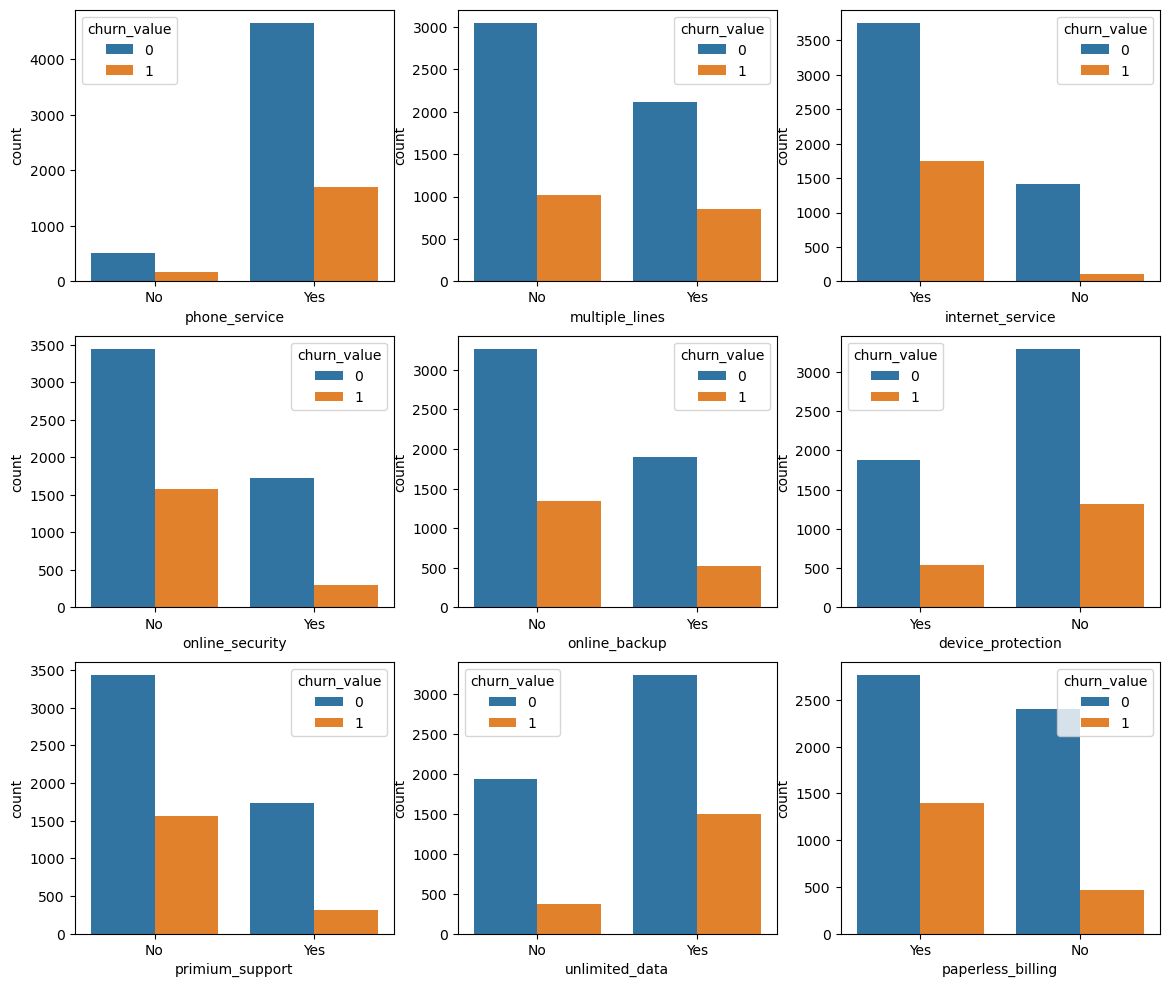

In [73]:
plt.figure(figsize=(14,12))

plt.subplot(3,3,1)
sns.countplot(data=df,x='phone_service', hue='churn_value')

plt.subplot(3,3,2)
sns.countplot(data=df,x='multiple_lines',hue='churn_value')

plt.subplot(3,3,3)
sns.countplot(data=df,x='internet_service',hue='churn_value')

plt.subplot(3,3,4)
sns.countplot(data=df,x='online_security',hue='churn_value')

plt.subplot(3,3,5)
sns.countplot(data=df,x='online_backup',hue='churn_value')

plt.subplot(3,3,6)
sns.countplot(data=df,x='device_protection',hue='churn_value')

plt.subplot(3,3,7)
sns.countplot(data=df,x='primium_support',hue='churn_value')

plt.subplot(3,3,8)
sns.countplot(data=df,x='unlimited_data',hue='churn_value')

plt.subplot(3,3,9)
sns.countplot(data=df,x='paperless_billing',hue='churn_value')



In [74]:
reason=df.groupby('reason_bucket')['churn_value'].count()
reason

reason_bucket
Competitor          841
Other              5899
Pricing             181
Service Quality      63
network issue        30
service              29
Name: churn_value, dtype: int64

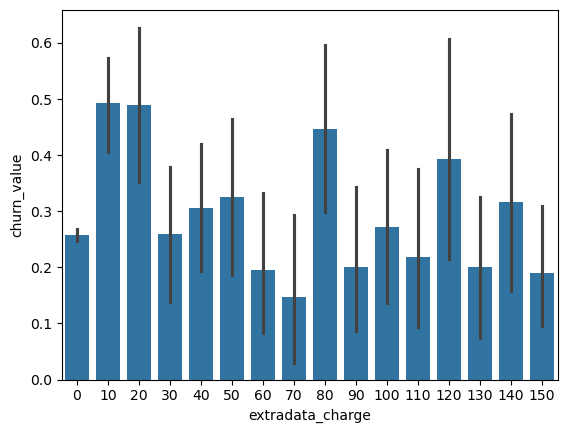

In [75]:
sns.barplot(data=df,x='extradata_charge',y='churn_value')
plt.show()

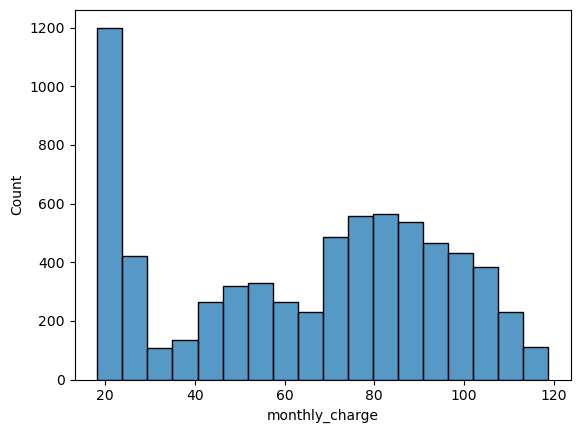

In [76]:
sns.histplot(df['monthly_charge'],kde=Tue)
plt.show()

In [77]:
df.groupby('churn_reason')['cltv'].mean().sort_values(ascending=False)

churn_reason
no mentioned                                 4490.921337
Price too high                               4305.179487
Deceased                                     4295.833333
Lack of self-service on Website              4294.862069
Competitor made better offer                 4244.247588
Limited range of services                    4238.459459
Product dissatisfaction                      4232.584416
Lack of affordable download/upload speed     4219.500000
Long distance charges                        4218.343750
Competitor offered more data                 4217.042735
Attitude of service provider                 4198.500000
Service dissatisfaction                      4196.587302
Competitor had better devices                4146.568690
Attitude of support person                   4145.513636
Poor expertise of online support             4140.483871
Network reliability                          4045.055556
Competitor offered higher download speeds    4020.570000
Don't know        

<Axes: xlabel='offer'>

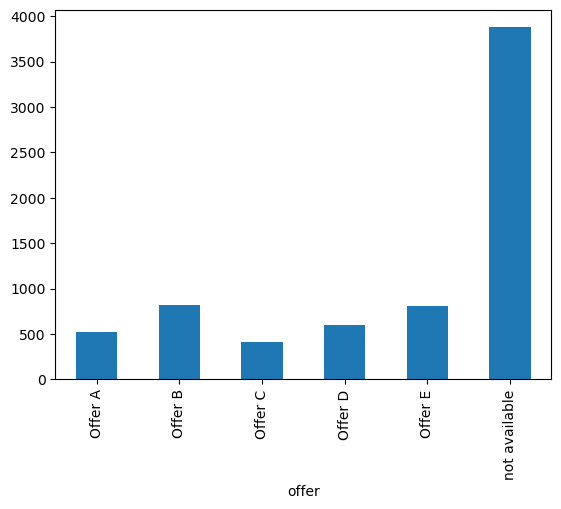

In [78]:
off=df.groupby('offer')['churn_value'].count()
off.plot(kind='bar')

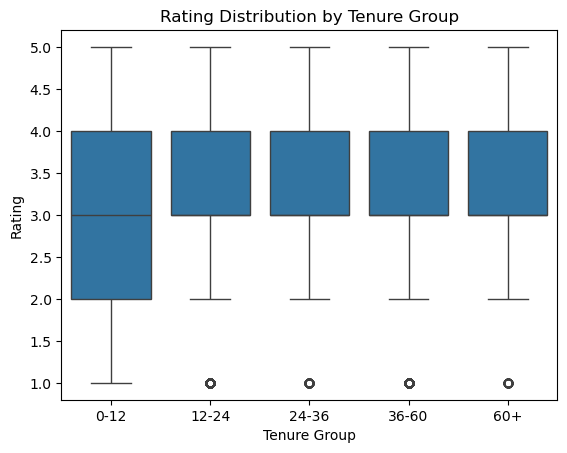

In [79]:
sns.boxplot(data=df, x='tenure_group', y='rating')
plt.xlabel('Tenure Group')
plt.ylabel('Rating')
plt.title('Rating Distribution by Tenure Group')
plt.show()



<Axes: xlabel='no_of_referrals', ylabel='churn_value'>

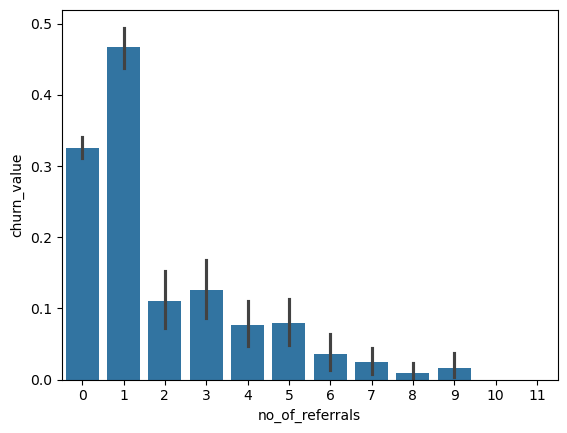

In [80]:
sns.barplot(data=df,x='no_of_referrals',y='churn_value')

In [81]:
df['no_of_referrals'].value_counts()

no_of_referrals
0     3821
1     1086
5      264
3      255
7      248
9      238
4      236
2      236
10     223
6      221
8      213
11       2
Name: count, dtype: int64

<Axes: >

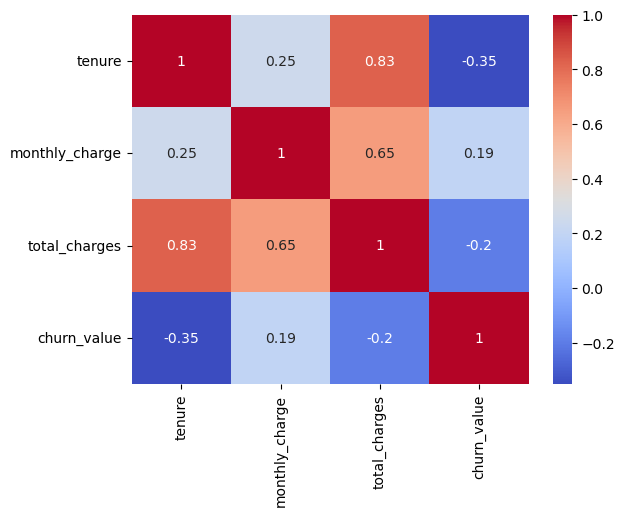

In [82]:
sns.heatmap(df[['tenure','monthly_charge','total_charges','churn_value']].corr(),
            annot=True, cmap='coolwarm')

<Axes: ylabel='revenue'>

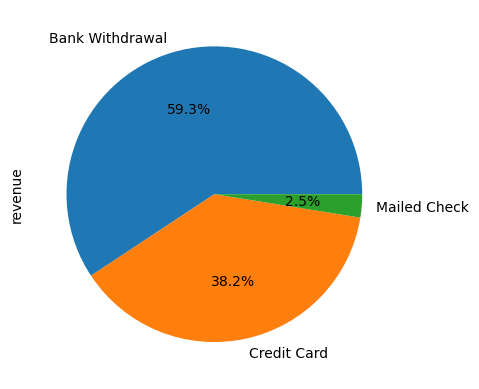

In [83]:
payments=df.groupby('pay_method')['revenue'].sum()
payments.plot(kind='pie',autopct='%0.1f%%')

In [84]:
df.groupby('pay_method')['churn_value'].sum()

pay_method
Bank Withdrawal    1329
Credit Card         398
Mailed Check        142
Name: churn_value, dtype: int64

<Axes: xlabel='monthly_charge', ylabel='Count'>

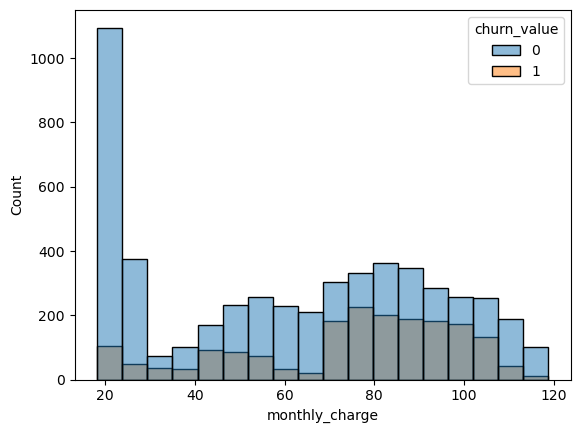

In [85]:
sns.histplot(data=df,x='monthly_charge',hue='churn_value')